# Opis projektu

Jednym ze sposobów zainicjowania fali tsunami jest podwodny uskok powstały w wyniku trzęsienia ziemii.

 Powstały uskok przybliżono dwuwymiarową funkcją Gaussa, która powstaje w określonym czasie. 


W projekcie wykorzystano model płytkiej wody oraz solver zbudowany na podstawie biblioteki PyMPDATA ułatwiającej numerykę.

Funkcje pomocnicze jaki i cała implementacja solvera znajduje się w pliku `utilities.py`

In [1]:
import os

os.environ["NUMBA_THREADING_LAYER"] = "omp"
os.environ["NUMBA_NUM_THREADS"] = "4"

import numpy as np
import matplotlib.pyplot as plt 
from matplotlib.animation import FuncAnimation
from open_atmos_jupyter_utils import show_plot, show_anim
from PyMPDATA import ScalarField, Solver, Stepper, VectorField, Options, boundary_conditions
from tabulate import tabulate
import pint
import scipy
from matplotlib.colors import LinearSegmentedColormap
from utilities import *
from IPython.display import HTML

In [2]:
cmap_bicolor = LinearSegmentedColormap.from_list("rho", ["#ff3647", "#FFFFFF", "#3B25FF"])
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 200.0

## Opis układu i warunki początkowe

### Siatka pomiarowa
Rzeczywista fala tsunami może powstawać w miejscach, gdzie głębokość wynosi 4km. Sam uskok generowany przez trzęsienie ziemii ma niewielki wkład do początkowej całkowitej wysokości słupa wody $h$, gdyż jego amplituda wynosi kilka metrów.
W symulacji uproszczono model, skupiając się na samym procesie tworzenia się fali w wyniku tworzącego się uskoku.

Następnie zdefiniowano podstawowe parametry symulacji: jej rozmiary `Lx = 500 m,`, `Ly = 200 m`; gęstość siatki `nx = 401`, `ny = 401`, całkowity czas symulacji `t_max = 40 s` oraz krok czasowy `dt = 0.02 s`.

In [3]:
si = pint.UnitRegistry()

Lx = 500 * si.m
Ly = 200 * si.m
nx, ny = 401, 401
dx, dy = Lx / nx, Ly / ny

t_max = 40 * si.s
dt = 0.02 * si.s
g = ( 9.81 * si.m / si.s**2 ).magnitude
nt = (t_max / dt).magnitude

h = 50 * si.m

H0 = ( h ).magnitude

## Parametry
Parametry uskoku zdefiniowano za pomocą klasy pomocniczej `UpliftParams`.

Uskok ma postać gaussa 2D, gdzie jego szerokość w osi Y jest 3 razy większa niż w osi x. Zasymulowano w ten sposób sytuację, gdzie fala tsunami porusza się głównie w osi X. Czas powstawania uskoku wybrano jako 1 s. Zaimplementowany solver zmodyfikowano zatem w taki sposób, by przyjmował funkcję aktualizującą początkową batymetrię dla zadanego przedziału czasowego. Funkcja ta liniowo zwiększa rozmiar uskoku aż do zadanej wartości amplitudy przez `uplift.magnitude`.


In [4]:
uplift = UpliftParams()
uplift.grid = nx, ny
uplift.magnitude = ( 10.0 * si.m ).magnitude
uplift.sigmas = 10 * si.m / dx, 30 * si.m / dy
uplift.center = 250 * si.m / dx, 100 * si.m / dy
uplift.tStart = ( 1 * si.s ).magnitude
uplift.tEnd = ( 2 * si.s ).magnitude
uplift.dt = dt.magnitude

dt_over_dxdy = (dt / dx).to_base_units().magnitude, (dt / dy).to_base_units().magnitude

v_max = np.sqrt(g*uplift.magnitude)
cfl_max = 0.25
dt_best = cfl_max * dx.magnitude / v_max

print(f"Wybrane dt = {dt:.3f}, wyliczone dt = {dt_best:.3f}.")

Wybrane dt = 0.020 second, wyliczone dt = 0.031.


In [5]:
dummy_grid = (10, 10)
dummy_output = ShallowWaterEquationsIntegrator(
    bathymetry=np.ones(dummy_grid),
    h_initial =np.ones(dummy_grid)
)(
    nt=5, g=10, dt_over_dxy=(0.001, 0.001), outfreq=1
)

del dummy_output

In [6]:
grid = (nx, ny)

bathymetry = np.ones(grid) * H0
h_initial = bathymetry.copy()
upliftCallback = createGaussianUplift(uplift)
outfreq = 4
output = ShallowWaterEquationsIntegrator(bathymetry=bathymetry,
    h_initial=h_initial
)(
    nt=int(nt), g=g, dt_over_dxy=dt_over_dxdy, outfreq=outfreq, bathymetryCallback=upliftCallback
)

# Wyniki symulacji

Poniżej przedstawiono przekrój fali tsunami dla $y=100$ m dla różnych chwili $t$.

In [7]:
t_arr = [2.0, 3.1, 8.0]
t_it = [int(t / dt.magnitude / outfreq) for t in t_arr]
x = np.linspace(0, Lx, nx).magnitude

y_normal = []

# colors = ['tomato', 'red', 'crimson']

# plt.figure(dpi=200, figsize=(8, 5))
# lws = [0.5, 1.0, 1.5]

for ti in t_it:
    psi = output['h'][ti] - output['bathymetry'][ti]
    y = psi[:, 200]
    y_normal.append(y)
    # plt.plot(x, y, label=f'$t = {ti * dt * outfreq:.2f~}$', lw=lws.pop(-1), color=colors.pop(0))

# plt.legend()
# plt.xlim(0, x[-1])
# plt.ylabel(r"Amplituda fali $\xi$ [m]")
# plt.xlabel("$x$ [m]")
# show_plot()

x_normal = x

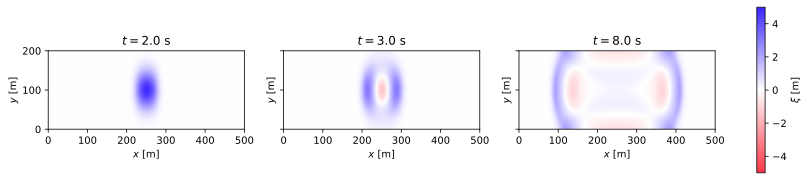

In [8]:
t_values = [2.0, 3.0, 8.0]

fig, axes = plt.subplots(1, 3, figsize=(15, 10), sharex=True, sharey=True)

x = np.linspace(0, Lx, nx).magnitude
y = np.linspace(0, Ly, ny).magnitude

for ax, t in zip(axes, t_values):
    t_idx = int(t / dt.magnitude / outfreq)

    im = ax.imshow(
        (output['h'][t_idx] - output['bathymetry'][t_idx]).T,
        extent=[x.min(), x.max(), y.min(), y.max()],
        cmap=cmap_bicolor,
        aspect='equal',
        vmin=-5,
        vmax=5
    )

    ax.set_title(f'$t = {t}$ s')
    ax.set_xlabel('$x$ [m]')
    ax.set_ylabel('$y$ [m]')

cbar = fig.colorbar(im, ax=axes, label=r'$\xi$ [m]', shrink=0.3)
show_plot()

Dla $t=2$ s obserwujemy koniec wypiętrzania się uskoku. Amplituda fali osiąga maksimum, a następnie rozlewa się na obie strony.

W kolejnych krokach obserwowane jest pomniejszenie się amplitudy i rozchodzenie się fali na brzegi.

Jest to oczekiwany rezultat. Pierwotnie fala przejmuje kształt uskoku, gdyż zmiana batymetrii wypycha ją do góry. Następnie fala rozlewa się na boki, gdyż energia potencjalna zgromadzona przez deformację dna przekształca się w energię kinetyczną.

W repozytorium na githubie rep/gifs umieszczono również pliki .gif animujące zachowanie się fali w widoku 1D jak przedstawiono powyżej, oraz 2D w postaci heatmapy (istotniejsze niż ploty statyczne). Na powyższym wykresie zauważalne jest również stopniowe pomniejszanie się amplitudy tsunami.
W rzeczywistości fala tsunami zwiększa swoją amplitudę z początkowych paru metrów. Wzrost amplitudy tsunami następuje na szelfie kontynentalnym, gdy fala wchodzi na płytsze wody.

# Energia fali

Na kolejnym wykresie przedstawiono wykres energii kinetycznej oraz potencjalnej utworzonej fali.

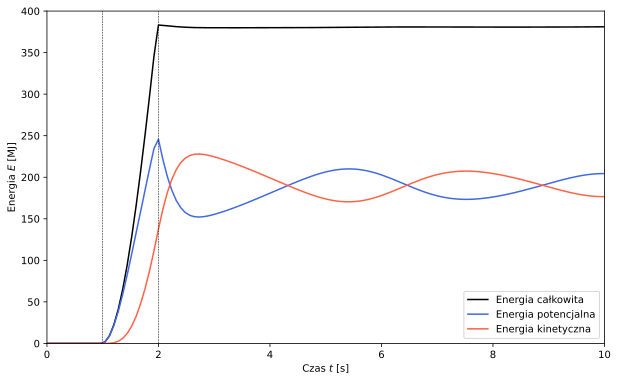

In [ ]:
e_p, e_k, e_tot = calculate_total_energy(output, dx.magnitude, dy.magnitude, 1000.0, g)

plt.figure(figsize=(10, 6))

norm = 1e6

e_p, e_k, e_tot = e_p / norm, e_k / norm, e_tot / norm

t = np.linspace(0, nt*dt.magnitude, len(output['h']))

plt.plot(t, e_tot, label='Energia całkowita', color='black')
plt.plot(t, e_p, label='Energia potencjalna', color='royalblue')
plt.plot(t, e_k, label='Energia kinetyczna', color='tomato')

plt.vlines(uplift.tStart, 0, 400, ls='--', lw=0.5, color='black')
plt.vlines(uplift.tEnd, 0, 400, ls='--', lw=0.5, color='black')

plt.xlabel('Czas $t$ [s]')
plt.ylabel('Energia $E$ [MJ]')
plt.xlim(0, 10)
plt.ylim(0, 400)
plt.legend()

show_plot();

Do chwili $t=1$ s całkowita energia jest równa zeru, następnie obserwujemy wzrost energii całkowitej przez okres powstawania uskoku do $t=2$ s. Obserwowane jest w tym momencie maksimum energii potencjalnej, która następnie zmienia się częściowo w energię kinetyczną. Następnie, energie: kinetyczna i potencjalna wykonują oscylacje stanowiąc średnio około połowy wkładu do energii całkowitej. Obserwujemy zachowanie się energii w pierwszych sekundach od powstania fali. Ze względu jednak na artefakty numeryczne jak i odbijanie się fali od brzegów całkowita wartość energi nieznacznie wzrasta przy dłuższym czasie symulacji. 

In [10]:
# for i in range(1, 6):
#     idx = i * 100
#     print(f"Energia dla t = {idx*dt*outfreq:~}: E = {e_tot[idx]:.2f} MJ")

rows = []
for i in range(1, 6):
    idx = i * 100
    rows.append([
        f"{idx * dt * outfreq:~}",   # czas
        f"{e_tot[idx]:.2f} MJ"       # energia
    ])

print(tabulate(rows, headers=["t", "E"], tablefmt="github"))

| t      | E         |
|--------|-----------|
| 8.0 s  | 380.68 MJ |
| 16.0 s | 382.72 MJ |
| 24.0 s | 385.18 MJ |
| 32.0 s | 385.66 MJ |
| 40.0 s | 389.27 MJ |


In [11]:
# czyszczenie pamięci
del output

# Prędkość fali

W tym modelu amplituda $\xi$ nie jest pomijalna względem batymetrii, zatem należy wziąć poprawkę i skorzystać ze wzoru uwzględniającego skończoną amplitudę fali
$$
    c = \sqrt{gh} (1 + \xi/2h).
$$

Prędkość fali sprawdzono wykonując symulację dla takich samych parametrów, zmieniając jedynie amplitudę uskoku od 1 do 20m.

In [12]:
t_max = 6.0 * si.s
nt = (t_max / dt).magnitude
uplift_magnitudes = np.linspace(1.0, 20.0, 5)

velocities_arr = []

dt =  0.01

nt = (t_max / dt).magnitude
dt_over_dxdy = (dt / dx).to_base_units().magnitude, (dt / dy).to_base_units().magnitude

uplift.dt = dt


for um in uplift_magnitudes:
    bathymetry = np.ones(grid) * H0
    h_initial = bathymetry.copy()
    uplift.magnitude = um
    upliftCallback = createGaussianUplift(uplift)

    output_vel = ShallowWaterEquationsIntegrator(bathymetry=bathymetry,
    h_initial=h_initial
    )(
        nt=int(nt), g=g, dt_over_dxy=dt_over_dxdy, outfreq=outfreq, bathymetryCallback=upliftCallback
    )

    velo = calculate_velocities(output_vel, dt, dx.magnitude, outfreq, g)
    velocities_arr.append(velo)

In [13]:
# for i in range(len(velocities_arr)):
#     v_f, v_t = velocities_arr[i]
#     err = abs(v_f - v_t) / v_t
#     mag = uplift_magnitudes[i]
#     print(f"Amplituda: {mag} m, prędkość wyznaczona: {v_f:.2f} m/s, teoretyczna: {v_t:.2f} m/s, różnica: {err:.2%}.")

rows = []
for i in range(len(velocities_arr)):
    v_f, v_t = velocities_arr[i]
    err = abs(v_f - v_t) / v_t
    mag = uplift_magnitudes[i]
    rows.append([
        f"{mag} m",
        f"{v_f:.2f} m/s",
        f"{v_t:.2f} m/s",
        f"{err:.2%}"
    ])

print(tabulate(
    rows,
    headers=["Amplituda", "Prędkość wyznaczona", "Teoretyczna", "Różnica"],
    tablefmt="github"
))

| Amplituda   | Prędkość wyznaczona   | Teoretyczna   | Różnica   |
|-------------|-----------------------|---------------|-----------|
| 1.0 m       | 22.94 m/s             | 22.20 m/s     | 3.33%     |
| 5.75 m      | 23.69 m/s             | 22.47 m/s     | 5.44%     |
| 10.5 m      | 24.69 m/s             | 22.73 m/s     | 8.63%     |
| 15.25 m     | 25.69 m/s             | 22.99 m/s     | 11.74%    |
| 20.0 m      | 26.43 m/s             | 23.25 m/s     | 13.68%    |


In [14]:
#czyszczenie pamięci
del output_vel
# del output_high_res

Zgodnie z przewidywaniami obserwowana jest większa prędkość rozchodzenia się fali tsunami dla większych amplitud uskoku. 
Błąd między wartością teoretyczną a wyznaczoną również się powiększa, gdyż przedstawiony wzór jest tylko przybliżeniem dla sytuacji, gdy amplituda fali nie jest pomijalna do głębokości wody.

In [15]:
si = pint.UnitRegistry()

Lx = 500 * si.m
Ly = 200 * si.m
nx, ny = 801, 801
dx, dy = Lx / nx, Ly / ny

t_max = 8.1 * si.s
dt = 0.01 * si.s
g = ( 9.81 * si.m / si.s**2 ).magnitude
nt = (t_max / dt).magnitude

h = 50 * si.m

H0 = ( h ).magnitude

uplift_2 = UpliftParams()
uplift_2.grid = nx, ny
uplift_2.magnitude = ( 10.0 * si.m ).magnitude
uplift_2.sigmas = 10 * si.m / dx, 30 * si.m / dy
uplift_2.center = 250 * si.m / dx, 100 * si.m / dy
uplift_2.tStart = ( 1 * si.s ).magnitude
uplift_2.tEnd = ( 2 * si.s ).magnitude
uplift_2.dt = dt.magnitude

dt_over_dxdy = (dt / dx).to_base_units().magnitude, (dt / dy).to_base_units().magnitude

v_max = np.sqrt(g*uplift_2.magnitude)
cfl_max = 0.25
dt_best = cfl_max * dx.magnitude / v_max

grid = (nx, ny)

bathymetry = np.ones(grid) * H0
h_initial = bathymetry.copy()
upliftCallback_2 = createGaussianUplift(uplift_2)
outfreq = 4
output_high_res = ShallowWaterEquationsIntegrator(bathymetry=bathymetry,
    h_initial=h_initial
)(
    nt=int(nt), g=g, dt_over_dxy=dt_over_dxdy, outfreq=outfreq, bathymetryCallback=upliftCallback_2
)

## Stabilność rozdzielcza symulacji

Analizę stabilności otrzymanych wyników przeprowadzono wykonując symulację dla dwukrotnie większej rozdzielczości siatki <br>
co wymagało również zmniejszenia kroku czasowego dwukrotnie. <br>
Wykres przedstawia ewolucję fali dla $y=100$ m dla czasów $t=2$ s, $t=3.1$ s oraz $t=8$ s.

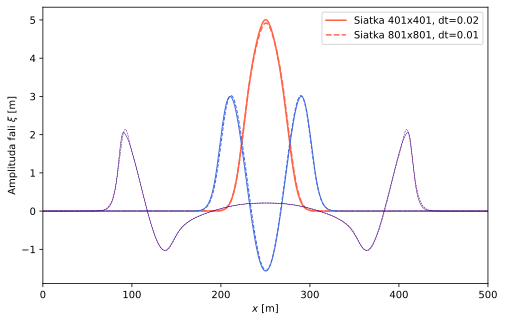

In [19]:
t_arr = [2.0, 3.1, 8.0]
t_it = [int(t / dt.magnitude / outfreq) for t in t_arr]
x = np.linspace(0, Lx, nx).magnitude
x2 = x_normal
colors = ['tomato', 'tomato', 'royalblue', 'royalblue', 'indigo', 'indigo']

plt.figure(dpi=200, figsize=(8, 5))
lws = [0.5, 0.5, 1.0, 1.0, 1.5, 1.5]

for i in range(len(t_it)):
    ti = t_it[i]
    psi = output_high_res['h'][ti] - output_high_res['bathymetry'][ti]
    y = psi[:, 400]
    y2 = y_normal[i]
    if i == 0:
        plt.plot(x, y, lw=lws.pop(-1), color=colors.pop(0), label='Siatka 401x401, dt=0.02')
        plt.plot(x2, y2, lw=lws.pop(-1), color=colors.pop(0), ls='--', label='Siatka 801x801, dt=0.01')
    else:
        plt.plot(x, y, lw=lws.pop(-1), color=colors.pop(0))
        plt.plot(x2, y2, lw=lws.pop(-1), color=colors.pop(0), ls='--')

plt.legend()
plt.xlim(0, x[-1])
plt.ylabel(r"Amplituda fali $\xi$ [m]")
plt.xlabel("$x$ [m]")
show_plot()

Na wykresie widoczna jest zbieżność otrzymanych wyników, tj. nie zaobserwowano znaczących różnić w symulacji dla zwiększonej rozdzielczości siatki, co świadczy o powtarzalności otrzymanych wyników.

## Podsumowanie i wnioski

W modelach symulujących propagację fali tsunami zaburzenie początkowe wody często przenoszone jest bezpośrednio z dna. 
Jednakże, gdy zasymulujemy proces tworzenia się impulsu poprzez zmienną batymetrię okazuje się, że początkowa amplituda fali tsunami jest mniejsza niż zaburzenie dna.

Wynika to z faktu, że deformacja dna jest procesem rozciągniętym w czasie, a nie natychmiastowym. W trakcie wypiętrzania słupa wody, siły grawitacji i gradienty ciśnienia natychmiastowo wymuszają poziomą propagację masy wodnej.

Dowodzi temu wykres energii dla rozchodzącej się fali, gdzie widać że w czasie tworzenia się zaburzeń energia kinetyczna nie jest zerowa, a rośnie wraz z energią potencjalną.
Rzeczywiście, energia potencjalna osiąga maksimum gdy dno przestanie się wypiętrzać, jednakże zgromadzona energia kinetyczna jest wystarczająca, by rozmycie wypiętrzenia było zauważalne.